In [1]:
import numpy as np 
import pandas as pd


In [2]:
df = pd.read_csv('house_listings.csv')

In [3]:
df.head()

,category,price,currency,price_1m2,title,address,floor,area,title_deed,repair,mortgage,url,room_number
0,Köhnə tikili,137 000,AZN,2 630 AZN/m²,"Satılır 3 otaqlı köhnə tikili 52 m², 8-ci kilo...",Elşən Süleymanov küç 137,7 / 9,52 m²,var,var,NaN,https://bina.az/items/3858477,3.0
1,Yeni tikili,183 000,AZN,1 790 AZN/m²,"Satılır 2 otaqlı yeni tikili 102 m², Neftçilər m.",Mehdi Abbasov küçəsi,2 / 17,102 m²,yoxdur,var,NaN,https://bina.az/items/3858493,2.0
2,Köhnə tikili,145 000,AZN,2 230 AZN/m²,"Satılır 2 otaqlı köhnə tikili 65 m², Nərimanov r.",Atatürk Prospekti,6 / 9,65 m²,var,var,var,https://bina.az/items/3858489,2.0
3,Köhnə tikili,190 000,AZN,2 000 AZN/m²,"Satılır 3 otaqlı köhnə tikili 95 m², Gənclik m.",Atatürk pr.,4 / 9,95 m²,var,var,var,https://bina.az/items/3858491,3.0
4,Yeni tikili,294 000,AZN,1 550 AZN/m²,"Satılır 3 otaqlı yeni tikili 190 m², Nəsimi r.",Möhsün Sənani küçəsi,6 / 16,190 m²,var,yoxdur,NaN,https://bina.az/items/3858488,3.0


## DATA CLEANING AND PRE-PROCESSING

In [4]:
df.size

461539

In [5]:
df.shape

(35503, 13)

In [6]:
df.dtypes

category           str
price              str
currency           str
price_1m2          str
title              str
address            str
floor              str
area               str
title_deed         str
repair             str
mortgage           str
url                str
room_number    float64
dtype: object

In [7]:
df.isna().sum()

category          37
price             37
currency          37
price_1m2         37
title             37
address           37
floor             37
area              37
title_deed        37
repair          1729
mortgage       23861
url                0
room_number       37
dtype: int64

In [8]:
# price sütundakı məlumat tipinin yoxlanılması
print(df['price'].dtype)

str


In [9]:
# price sütunu üzrə tip çevrilməsi 
df['price'] = df['price'].str.replace(' ','').astype(float)

In [10]:
# price_1m2 sütunu üzrə tip çevrilməsi
df['price_1m2'] = df['price_1m2'].str.removesuffix('AZN/m²').str.replace(' ','').astype(float)

In [11]:
# area sütunu üzrə tip çevrilməsi 
df['area'] = df['area'].str.removesuffix('m²').astype(float)

In [12]:
df['current_floor'] = df['floor'].str.rpartition('/')[0]
df['total_floor'] = df['floor'].str.rpartition('/')[2]

df['current_floor'] = pd.to_numeric(df['current_floor'], errors='coerce').astype('Int64')
df['total_floor'] = pd.to_numeric(df['total_floor'], errors='coerce').astype('Int64')
df.drop(columns='floor',inplace=True)

In [13]:
df.isna().sum()

category            37
price               37
currency            37
price_1m2           37
title               37
address             37
area                37
title_deed          37
repair            1729
mortgage         23861
url                  0
room_number         37
current_floor       37
total_floor         37
dtype: int64

In [14]:
df['mortgage'] = df['mortgage'].fillna('məlumat yoxdur')

In [15]:
df['repair'] = df['repair'].fillna('məlumat yoxdur')

In [16]:
df.dropna(inplace=True)

In [17]:
df.isna().sum()

category         0
price            0
currency         0
price_1m2        0
title            0
address          0
area             0
title_deed       0
repair           0
mortgage         0
url              0
room_number      0
current_floor    0
total_floor      0
dtype: int64

In [18]:
df.dtypes

category             str
price            float64
currency             str
price_1m2        float64
title                str
address              str
area             float64
title_deed           str
repair               str
mortgage             str
url                  str
room_number      float64
current_floor      Int64
total_floor        Int64
dtype: object

### DESCRIPTIVE STATISTICS


In [19]:
# Mənzil qiymətinin ortalama dəyəri 
print(f'Mənzil qiymətlərini ortalama dəyəri: {df["price"].mean()} AZN')

# Mənzil qiymətinin medianı
print(f'Mənzil qiymətlərini medianı: {df["price"].median()} AZN')

# Mənzil qiymətlərinin modası 
print(f'Mənzil qiymətlərini modu: {df["price"].mode()} AZN')


# Burada mean > median > mode olduğu üçün right skewness yəni  sağa doğru pozitiv əyilmə var 


Mənzil qiymətlərini ortalama dəyəri: 237061.2840466926 AZN
Mənzil qiymətlərini medianı: 192000.0 AZN
Mənzil qiymətlərini modu: 0    135000.0
Name: price, dtype: float64 AZN


In [20]:
# price 1m2 üçün standard kənarlaşma variasiya və İQR hesaplanması
print(f'price_1m2 üçün standard deviation {df["price_1m2"].std()}')

# price 1m2 üçün variasiya
print(f'price_1m2 üçün variasiya {df["price_1m2"].var()}')

print(f"IQR = {df['price_1m2'].quantile(0.75) - df['price_1m2'].quantile(0.25)}")

price_1m2 üçün standard deviation 690.5218188387937
price_1m2 üçün variasiya 476820.3822924359
IQR = 700.0


In [21]:
result = df.groupby("category").agg(
    avg_area=("area", "mean"),
    median_room=("room_number", "median")
)

result

,avg_area,median_room
category,,
Köhnə tikili,71.646929,3.0
Yeni tikili,117.598365,3.0


In [22]:
repair = pd.DataFrame({'frequency':df['repair'].value_counts(),
                       'frequency_percent': df['repair'].value_counts()/len(df)*100})
repair

,frequency,frequency_percent
repair,,
var,28371,79.994925
yoxdur,5403,15.234309
məlumat yoxdur,1692,4.770766


In [23]:
title_deed = pd.DataFrame({'frequency':df['title_deed'].value_counts(),
                       'frequency_percent': df['title_deed'].value_counts()/len(df)*100})
title_deed

,frequency,frequency_percent
title_deed,,
var,27259,76.859527
yoxdur,8207,23.140473


In [24]:
df[['area','room_number','price']].corr()

,area,room_number,price
area,1.000000,0.777706,0.82237
room_number,0.777706,1.000000,0.60291
price,0.822370,0.602910,1.00000


In [25]:
z_score = (df["price"] - df["price"].mean()) / df["price"].std()

outlier_index = df[z_score.abs() > 3].index


In [26]:
outliers = df[z_score.abs() > 3]

outliers.head()

,category,price,currency,price_1m2,title,address,area,title_deed,repair,mortgage,url,room_number,current_floor,total_floor
19,Yeni tikili,950000.0,AZN,4040.0,"Satılır 5 otaqlı yeni tikili 234.9 m², Şah İsm...",A.Cəlilov küç,234.9,var,var,məlumat yoxdur,https://bina.az/items/3858461,5.0,13,26
256,Yeni tikili,1100000.0,AZN,5120.0,"Satılır 4 otaqlı yeni tikili 215 m², İçəri Şəh...",Nizami küçəsi 50,215.0,var,var,var,https://bina.az/items/3206879,4.0,7,14
310,Yeni tikili,1700000.0,AZN,6910.0,"Satılır 5 otaqlı yeni tikili 246 m², Sahil m.",Üzeyir Hacıbəyli küçəsi,246.0,var,var,məlumat yoxdur,https://bina.az/items/3435822,5.0,3,9
471,Yeni tikili,1100000.0,AZN,4580.0,"Satılır 6 otaqlı yeni tikili 240 m², İçəri Şəh...",Səid Rüstəmov küç. 9,240.0,var,yoxdur,məlumat yoxdur,https://bina.az/items/3857802,6.0,8,14
533,Yeni tikili,1550000.0,AZN,3510.0,"Satılır 5 otaqlı yeni tikili 442 m², Ağ şəhər q.",Mərkəzi Bulvar küçəsi,442.0,yoxdur,yoxdur,məlumat yoxdur,https://bina.az/items/3784531,5.0,19,20


In [27]:
# Outlierların ümumi sayı və tezliyi 
print('Outlierların ümumi sayı: ',len(outliers),'\nBuda datasetin ',len(outliers)/len(df)*100,'% dir')

Outlierların ümumi sayı:  472 
Buda datasetin  1.3308520836857836 % dir


### DATA VIZUALATION

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# bin sayının tapılması
bins = 1 + np.ceil(np.log2(len(df)))
bins

np.float64(17.0)

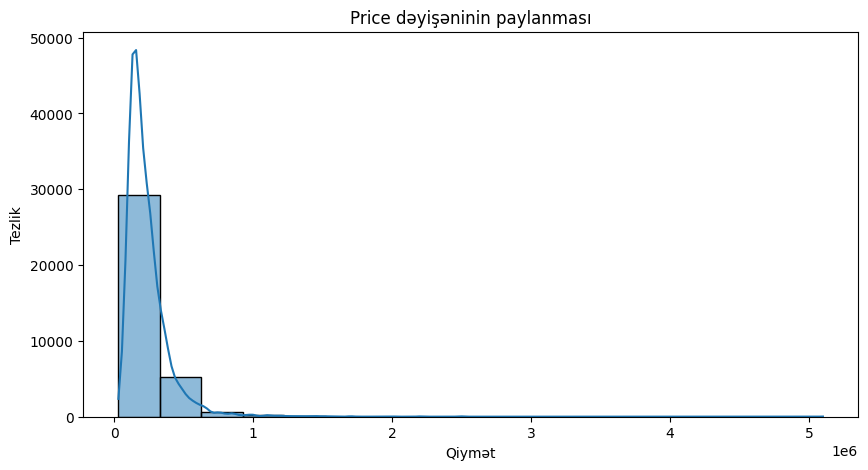

In [78]:
plt.figure(figsize = (10,5))
sns.histplot(data= df,x='price',kde=True,bins = 17)
plt.title("Price dəyişəninin paylanması")
plt.xlabel("Qiymət")
plt.ylabel("Tezlik")
plt.savefig('histplot.png',dpi = 1000)
plt.show()


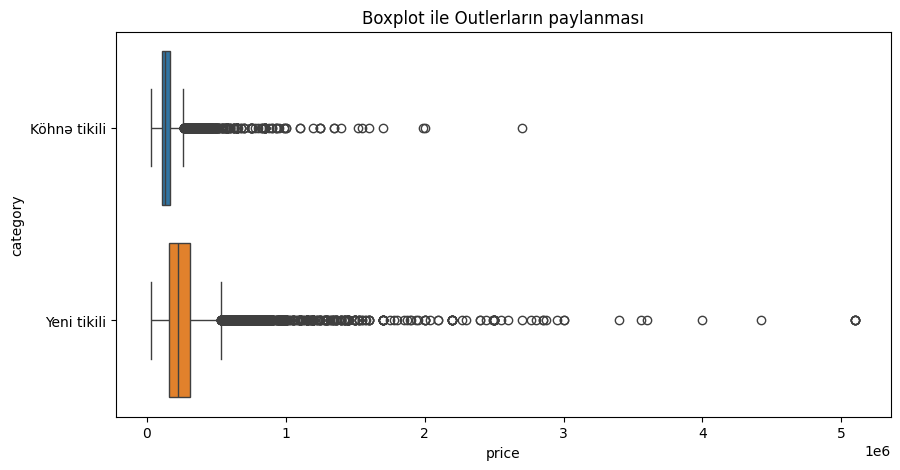

In [77]:
plt.figure(figsize = (10,5))
sns.boxplot(data =df,x = 'price',y='category',hue='category')
plt.title("Boxplot ile Outlerların paylanması")
plt.savefig('boxplot.png',dpi = 1000)
plt.show()

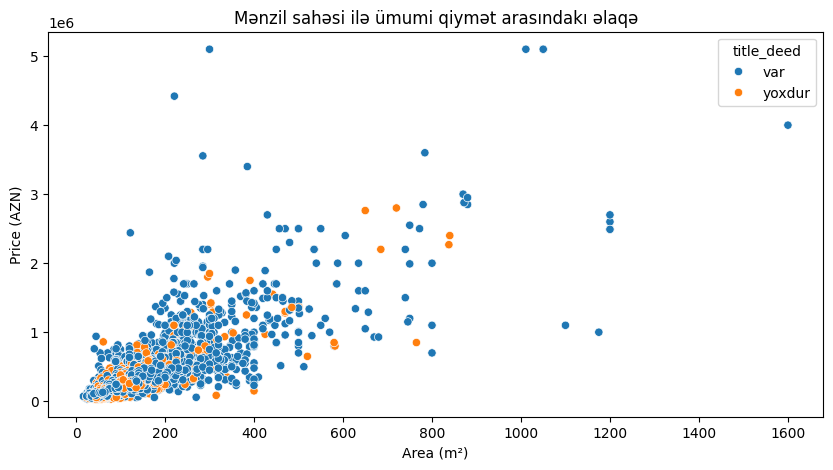

In [76]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df,x='area',y = 'price',color = 'green',hue='title_deed')
plt.title("Mənzil sahəsi ilə ümumi qiymət arasındakı əlaqə")
plt.xlabel("Area (m²)")
plt.ylabel("Price (AZN)")
plt.savefig('scatterplot.png',dpi = 1000)
plt.show()

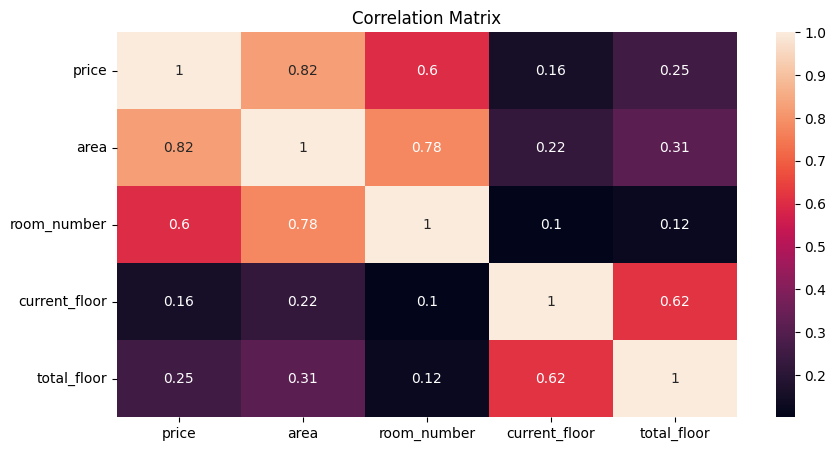

In [75]:
plt.figure(figsize = (10,5))
corr_rel = df[['price','area','room_number','current_floor','total_floor']].corr()
sns.heatmap(data = corr_rel,annot=True)
plt.title('Correlation Matrix')
plt.savefig('heatmap.png',dpi = 1000)
plt.show()

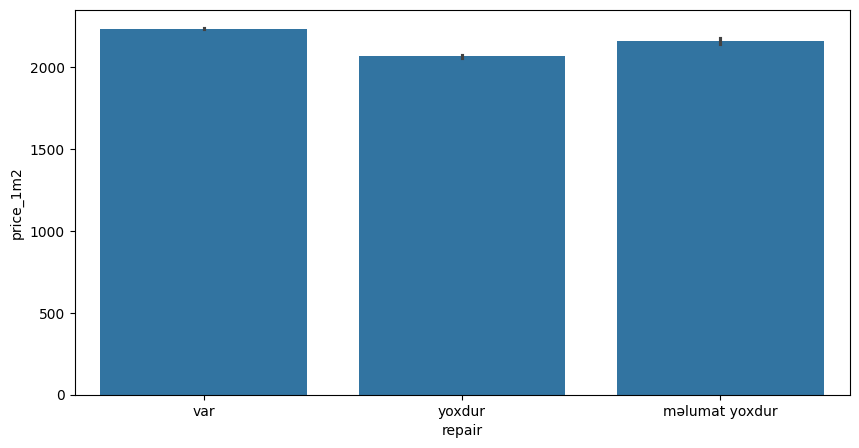

In [74]:
plt.figure(figsize = (10,5))
sns.barplot(data = df,x = 'repair',y = 'price_1m2',errorbar='se')
plt.savefig('barplott.png',dpi = 1000)
plt.show()

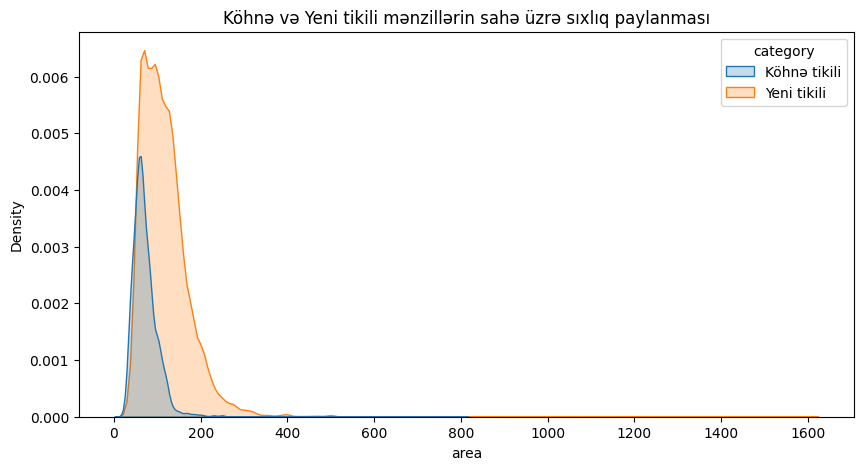

In [73]:
plt.figure(figsize = (10,5))
sns.kdeplot(data = df,x = 'area',hue='category',fill=True)
plt.title("Köhnə və Yeni tikili mənzillərin sahə üzrə sıxlıq paylanması")
plt.savefig('kdeplot.png',dpi = 1000)
plt.show()

<Figure size 1000x500 with 0 Axes>

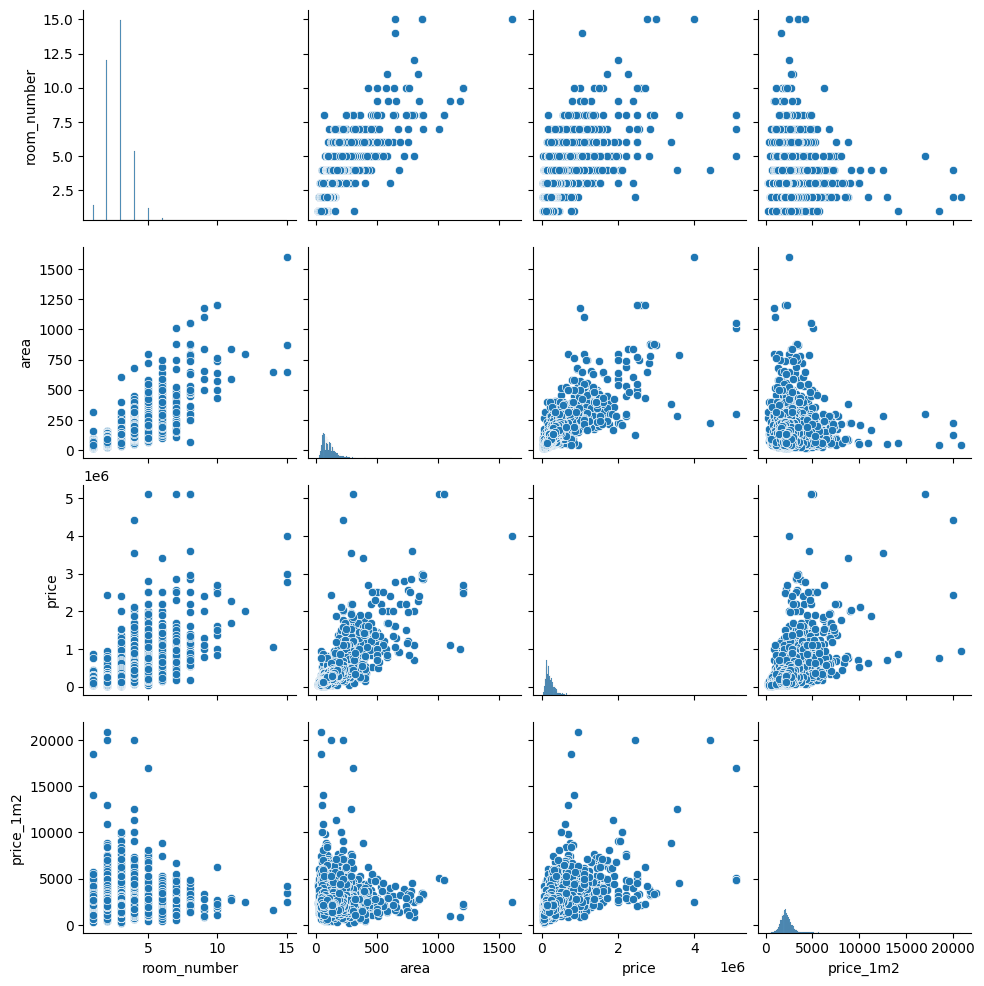

In [72]:
plt.figure(figsize = (10,5))
sns.pairplot(df[['room_number','area', 'price', 'price_1m2']])
plt.savefig('pairplot.png',dpi = 1000)
plt.show()

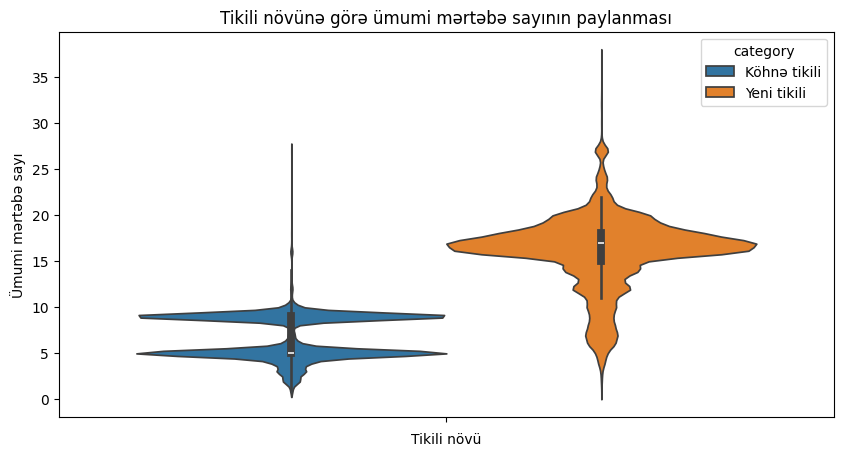

In [71]:
plt.figure(figsize = (10,5))
sns.violinplot(data = df, y = 'total_floor',hue = 'category')
plt.title("Tikili növünə görə ümumi mərtəbə sayının paylanması")
plt.xlabel("Tikili növü")
plt.ylabel("Ümumi mərtəbə sayı")
plt.savefig('violinplot.png',dpi = 1000)
plt.show()